> **Tip**: Welcome to the Investigate a Dataset project! You will find tips in quoted sections like this to help organize your approach to your investigation. Once you complete this project, remove these **Tip** sections from your report before submission. First things first, you might want to double-click this Markdown cell and change the title so that it reflects your dataset and investigation.

# Project: Investigate a Dataset - TMDb Movie Data: What Is Associated With Movie Success?

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

This project analyzes the **TMDb movie dataset**, which contains information on
**10,866 movies** collected from [The Movie Database (TMDb)](https://www.themoviedb.org/).
The data was cleaned by Udacity from the original
[Kaggle release](https://www.kaggle.com/tmdb/tmdb-movie-metadata). It is a single
table with **21 columns**:

| Column | Description |
| --- | --- |
| `id` | TMDb identifier for the movie |
| `imdb_id` | IMDb identifier (e.g. `tt0369610`) |
| `popularity` | TMDb popularity score (relative, unbounded) |
| `budget` | Production budget in nominal US dollars |
| `revenue` | Box-office revenue in nominal US dollars |
| `original_title` | Title of the movie |
| `cast` | Lead actors, pipe-separated (`|`), capped at five names |
| `homepage` | Official website URL |
| `director` | Director(s) of the movie |
| `tagline` | Marketing tagline |
| `keywords` | Plot keywords, pipe-separated (`|`) |
| `overview` | Short plot summary |
| `runtime` | Length of the movie in minutes |
| `genres` | Genres, pipe-separated (`|`) |
| `production_companies` | Production companies, pipe-separated (`|`) |
| `release_date` | Release date (stored as text) |
| `vote_count` | Number of user votes |
| `vote_average` | Average user rating (0–10) |
| `release_year` | Year of release (integer) |
| `budget_adj` | Budget in inflation-adjusted 2010 US dollars |
| `revenue_adj` | Revenue in inflation-adjusted 2010 US dollars |

A few characteristics are important for the analysis. Four columns (`cast`,
`keywords`, `genres`, `production_companies`) store **multiple pipe-separated
values** in a single field. The `budget_adj` and `revenue_adj` columns express money
in **2010 dollars**, which makes financial comparisons across decades fair, so they
are preferred over the raw `budget` / `revenue` columns. Finally, several numeric
columns use `0` to encode missing data (notably `budget`, `revenue`, and `runtime`),
which is addressed in the Data Wrangling section.

### Question(s) for Analysis

This report investigates what is associated with a movie's **success**, using two
complementary outcome measures as the primary **dependent variables**:

- **`revenue_adj`** — box-office revenue in inflation-adjusted 2010 US dollars, and
- **`vote_average`** — the average TMDb user rating.

These outcomes are explored against several **independent variables** — listed cast
size, release year, actor prolificness, production budget, and genre — through the
following four questions:

1. **Cast size over time and success:** How has the number of *listed* cast members
   changed across release years, and is listed cast size related to a movie's
   revenue? *(independent variables: listed cast size, `release_year`)*
2. **Small-cast performance:** Do movies with small listed casts (1–3 names) perform
   differently from full 5-listed-cast movies on revenue, rating, and popularity?
   *(independent variable: listed cast-size group)*
3. **Veteran stars:** Do movies featuring a prolific/veteran actor — measured by the
   number of films an actor appears in within this dataset — earn more or score
   higher than movies without one? *(independent variables: presence of a prolific
   actor, `budget_adj`)*
4. **Genre landscape:** Which genres are associated with higher ratings versus higher
   revenue, and where do niche illness/"dementia" themes sit within that landscape?
   *(independent variable: `genres`)*

Each question is explored with both single-variable (1d) and multiple-variable (2d)
views, and each carries a clearly stated limitation (for example, the `cast` column
is capped at five names, and film count is only a proxy for an actor's seniority).

> **Tip**: Once you start coding, use NumPy arrays, Pandas Series, and DataFrames where appropriate rather than Python lists and dictionaries. Also, **use good coding practices**, such as, define and use functions to avoid repetitive code. Use appropriate comments within the code cells, explanation in the mark-down cells, and meaningful variable names. 

In [1]:
# Use this cell to set up import statements for all of the packages that you
#   plan to use.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Magic word so that visualizations are plotted inline with the notebook.
%matplotlib inline

# Set a consistent style for all plots in the report.
sns.set_style('darkgrid')

<a id='wrangling'></a>
## Data Wrangling

> **Tip**: In this section of the report, you will load in the data, check for cleanliness, and then trim and clean your dataset for analysis. Make sure that you **document your data cleaning steps in mark-down cells precisely and justify your cleaning decisions.**


### General Properties
> **Tip**: You should _not_ perform too many operations in each cell. Create cells freely to explore your data. One option that you can take with this project is to do a lot of explorations initially. This does not have to be organized, but make sure you use enough comments to understand the purpose of each code cell. Then, after you're done with your analysis, trim the excess and organize your steps so that you have a flowing, cohesive report.

In [2]:
# Load the TMDb movie dataset into a DataFrame.
df = pd.read_csv('Database_TMDb_movie_data/tmdb-movies.csv')

# Look at the size of the dataframe (rows, columns) and the first few rows.
print('Shape (rows, columns):', df.shape)
df.head()

Shape (rows, columns): (10866, 21)


,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [3]:
# Inspect column data types and non-null counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  str    
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  str    
 6   cast                  10790 non-null  str    
 7   homepage              2936 non-null   str    
 8   director              10822 non-null  str    
 9   tagline               8042 non-null   str    
 10  keywords              9373 non-null   str    
 11  overview              10862 non-null  str    
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  str    
 14  production_companies  9836 non-null   str    
 15  release_date          10866 no

**Observation — structure and data types**

The dataset has **10,866 rows and 21 columns**: 6 integer, 4 float, and 11 text (`str`) columns. A few things to note for cleaning:

- `release_date` is stored as text rather than a datetime, but `release_year` is already available as an integer for year-based analysis.
- Columns such as `cast`, `genres`, `keywords`, and `production_companies` store multiple pipe-separated (`|`) values in a single field.
- The `id` and `imdb_id` columns are identifiers, not measurements.

In [4]:
# Summary statistics for the numeric columns.
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


**Observation — summary statistics**

A few numeric columns contain implausible zero values that almost certainly represent missing data recorded as `0` rather than true measurements:

- `budget` / `budget_adj`: **5,696** movies have a value of 0.
- `revenue` / `revenue_adj`: **6,016** movies have a value of 0.
- `runtime`: **31** movies have a runtime of 0.

`release_year` ranges from **1960 to 2015**. These zero-as-missing values will need to be handled before any analysis involving budget, revenue, or runtime.

In [5]:
# Count missing values per column (show only columns that have any).
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

homepage                7930
tagline                 2824
keywords                1493
production_companies    1030
cast                      76
director                  44
genres                    23
imdb_id                   10
overview                   4
dtype: int64

**Observation — missing values**

Several columns contain missing values. The text/descriptive columns are the most affected: `homepage` (7,930 missing), `tagline` (2,824), `keywords` (1,493), and `production_companies` (1,030). A smaller number are missing in `cast` (76), `director` (44), `genres` (23), `imdb_id` (10), and `overview` (4).

None of the core numeric columns used for analysis (`popularity`, `budget_adj`, `revenue_adj`, `runtime`, `vote_average`, `vote_count`, `release_year`) have `NaN` values.

In [6]:
# Check for fully duplicated rows.
df.duplicated().sum()

np.int64(1)

**Observation — duplicates**

There is exactly **1 fully duplicated row** in the dataset. It will be removed during the Data Cleaning step.


### Data Cleaning
> **Tip**: Make sure that you keep your reader informed on the steps that you are taking in your investigation. Follow every code cell, or every set of related code cells, with a markdown cell to describe to the reader what was found in the preceding cell(s). Try to make it so that the reader can then understand what they will be seeing in the following cell(s).

Based on the inspection above, the cleaning plan is:

1. **Remove the single fully duplicated row.**
2. **Treat zeros as missing.** `budget`, `revenue`, `budget_adj`, `revenue_adj`, and
   `runtime` use `0` to encode missing measurements. We convert those zeros to `NaN`
   so that financial/runtime analyses can drop them per question rather than deleting
   whole rows up front (which would needlessly discard movies that still have valid
   ratings, genres, and cast information).
3. **Leave descriptive text columns as-is.** Missing values in `homepage`, `tagline`,
   `keywords`, etc. are not central to the questions, so no rows are dropped for them.

The steps are implemented as small, **reusable functions** so the same logic can be
applied to other datasets that share these common problems (duplicate rows and
zero-coded missing values).


In [7]:
# --- Reusable, dataset-agnostic data-cleaning helpers ---
# These functions take any DataFrame so the same cleaning logic can be reused on
# other datasets, not just this one.

def drop_full_duplicates(data, verbose=True):
    """Return a copy of `data` with exact duplicate rows removed and the index reset."""
    n_before = len(data)
    cleaned = data.drop_duplicates().reset_index(drop=True)
    if verbose:
        print(f'Removed {n_before - len(cleaned)} duplicate row(s); {len(cleaned)} rows remain.')
    return cleaned


def zeros_to_nan(data, columns, verbose=True):
    """Return a copy of `data` where 0 values in `columns` are treated as missing (NaN).

    Useful whenever a dataset encodes missing measurements as 0 instead of NaN.
    """
    cleaned = data.copy()
    for col in columns:
        n_zeros = int((cleaned[col] == 0).sum())
        cleaned[col] = cleaned[col].replace(0, np.nan)
        if verbose:
            print(f'{col}: converted {n_zeros} zero value(s) to NaN.')
    return cleaned

In [8]:
# Apply the reusable cleaning helpers to build the analysis DataFrame `df_clean`.
# Columns where 0 means "missing" rather than a true measurement.
zero_as_missing = ['budget', 'revenue', 'budget_adj', 'revenue_adj', 'runtime']

df_clean = drop_full_duplicates(df)
df_clean = zeros_to_nan(df_clean, zero_as_missing)
print('Cleaned shape (rows, columns):', df_clean.shape)

Removed 1 duplicate row(s); 10865 rows remain.
budget: converted 5696 zero value(s) to NaN.
revenue: converted 6016 zero value(s) to NaN.
budget_adj: converted 5696 zero value(s) to NaN.
revenue_adj: converted 6016 zero value(s) to NaN.
runtime: converted 31 zero value(s) to NaN.
Cleaned shape (rows, columns): (10865, 21)


In [9]:
# Confirm the cleaning worked: no duplicates remain and zeros became NaN.
print('Duplicate rows remaining:', df_clean.duplicated().sum())
df_clean[zero_as_missing].isnull().sum()

Duplicate rows remaining: 0


budget         5696
revenue        6016
budget_adj     5696
revenue_adj    6016
runtime          31
dtype: int64

**Result of cleaning**

The cleaned DataFrame `df_clean` has **10,865 rows** (the one duplicate removed). The
zero-as-missing conversion turned `budget`/`budget_adj` into 5,696 `NaN`s,
`revenue`/`revenue_adj` into 6,016 `NaN`s, and `runtime` into 31 `NaN`s. No rows were
dropped for these, so movies still contribute to rating-, genre-, and cast-based
analyses even when their budget or revenue is unknown. From here on, the analysis
uses `df_clean`.

<a id='eda'></a>
## Exploratory Data Analysis

> **Tip**: Now that you've trimmed and cleaned your data, you're ready to move on to exploration. **Compute statistics** and **create visualizations** with the goal of addressing the research questions that you posed in the Introduction section. You should compute the relevant statistics throughout the analysis when an inference is made about the data. Note that at least two or more kinds of plots should be created as part of the exploration, and you must  compare and show trends in the varied visualizations. Remember to utilize the visualizations that the pandas library already has available.



> **Tip**: Investigate the stated question(s) from multiple angles. It is recommended that you be systematic with your approach. Look at one variable at a time, and then follow it up by looking at relationships between variables. You should explore at least three variables in relation to the primary question. This can be an exploratory relationship between three variables of interest, or looking at how two independent variables relate to a single dependent variable of interest. Lastly, you  should perform both single-variable (1d) and multiple-variable (2d) explorations.

### Shared analysis helpers

Before exploring the individual questions, we define a small set of **reusable
helper functions** used throughout the EDA: `count_pipe_items` (to count
pipe-separated values such as cast or genres) and `style_axes` (to apply a
consistent title and axis labels to every plot). Defining them once keeps the
analysis DRY and ensures all figures are labelled the same way.

In [10]:
# --- Reusable helpers used across all of the analysis questions ---

def count_pipe_items(series):
    """Number of pipe-separated ('|') items in each value of a text Series.

    Missing values count as 0. Generic for any '|'-delimited column
    (cast, genres, keywords, production_companies, ...).
    """
    return series.fillna('').apply(lambda s: sum(1 for item in s.split('|') if item))


def style_axes(ax, title, xlabel, ylabel):
    """Apply a consistent title and axis labels to a matplotlib Axes and return it."""
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

<a id='rq1'></a>
### Research Question 1: Cast size over time and success

Here we derive **`cast_count`** — the number of *listed* cast members per movie — and
explore it from several angles:

- **1d:** the overall distribution of listed cast size.
- **2d:** how the mean listed cast size has changed across `release_year`, and how
  listed cast size relates to inflation-adjusted revenue (`revenue_adj`).

Recall from the dataset description that the `cast` field is **capped at five names**,
so `cast_count` measures how many names TMDb listed, not a movie's true ensemble size.

In [11]:
# Derive the number of listed cast members per movie using the reusable helper.
df_clean['cast_count'] = count_pipe_items(df_clean['cast'])

# 1d look: summary statistics and the distribution of listed cast size.
print(df_clean['cast_count'].describe())
df_clean['cast_count'].value_counts().sort_index()

count    10865.000000
mean         4.838288
std          0.710151
min          0.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: cast_count, dtype: float64


cast_count
0       76
1      144
2       90
3      109
4      313
5    10133
Name: count, dtype: int64

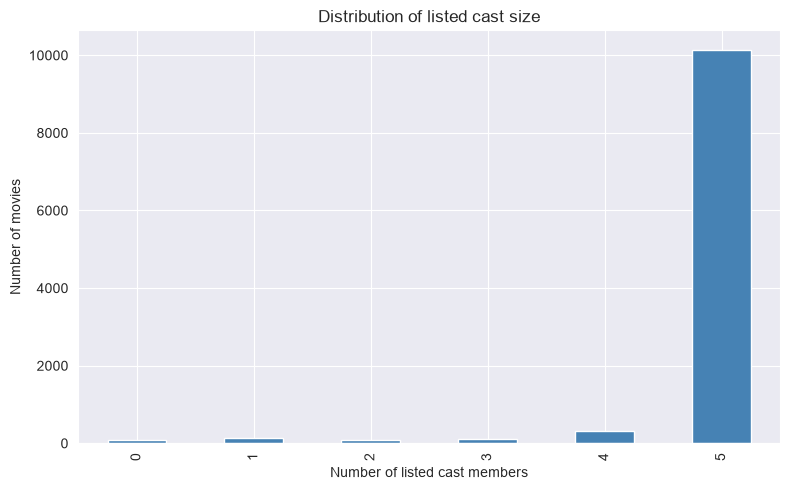

In [12]:
# 1d: visualize the distribution of listed cast size.
cast_counts = df_clean['cast_count'].value_counts().sort_index()

ax = cast_counts.plot(kind='bar', figsize=(8, 5), color='steelblue')
style_axes(ax, 'Distribution of listed cast size',
           'Number of listed cast members', 'Number of movies')
plt.tight_layout()
plt.show()

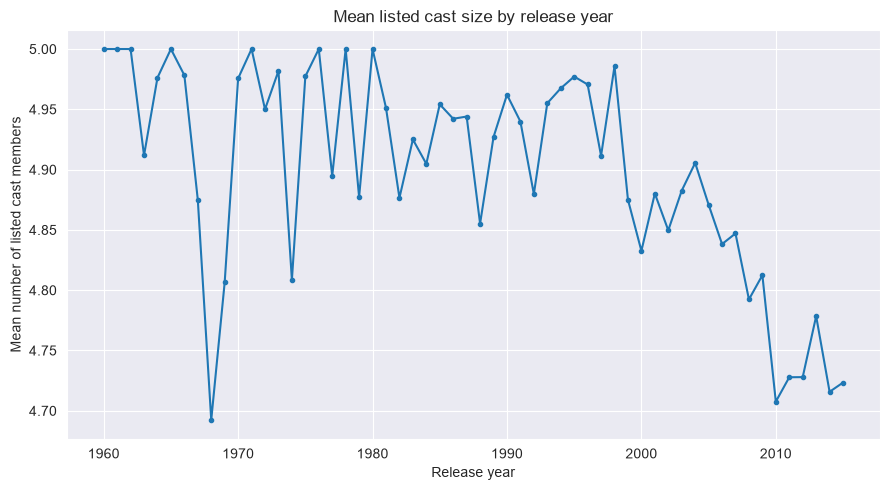

In [13]:
# 2d over time: how has the mean listed cast size changed across release years?
mean_cast_by_year = df_clean.groupby('release_year')['cast_count'].mean()

ax = mean_cast_by_year.plot(kind='line', figsize=(9, 5), marker='.')
style_axes(ax, 'Mean listed cast size by release year',
           'Release year', 'Mean number of listed cast members')
plt.tight_layout()
plt.show()

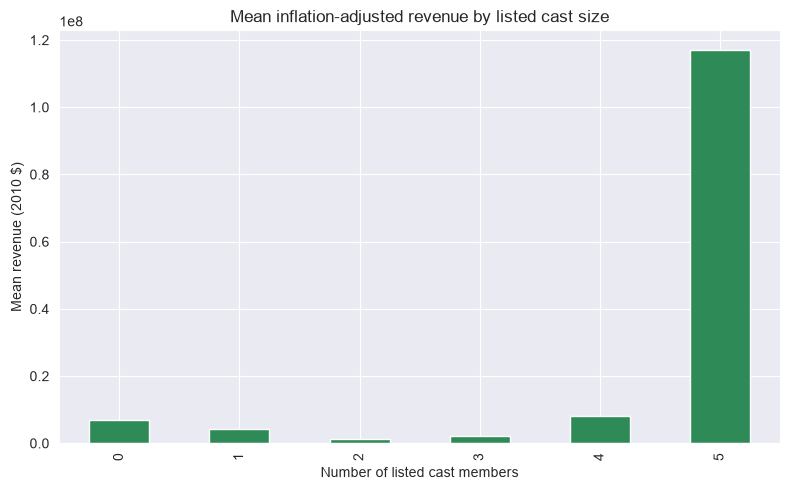

Correlation (cast_count vs revenue_adj): 0.060


In [14]:
# 2d: relationship between listed cast size and inflation-adjusted revenue.
mean_revenue_by_cast = df_clean.groupby('cast_count')['revenue_adj'].mean()

ax = mean_revenue_by_cast.plot(kind='bar', figsize=(8, 5), color='seagreen')
style_axes(ax, 'Mean inflation-adjusted revenue by listed cast size',
           'Number of listed cast members', 'Mean revenue (2010 $)')
plt.tight_layout()
plt.show()

# Correlation between cast size and revenue (movies with a known revenue).
corr = df_clean[['cast_count', 'revenue_adj']].dropna().corr().iloc[0, 1]
print(f'Correlation (cast_count vs revenue_adj): {corr:.3f}')

In [15]:
# Is the downward time trend real, or just a cataloguing artifact?
# Compare movie volume and how completely casts are listed across eras.
era = df_clean.groupby('release_year')
completeness = pd.DataFrame({
    'n_movies': era.size(),
    'mean_cast': era['cast_count'].mean().round(2),
    'pct_listing_under_5': (era['cast_count'].apply(lambda s: (s < 5).mean()) * 100).round(1),
})

print('Movies in dataset  —  1960s:', int(df_clean[df_clean['release_year'] < 1970].shape[0]),
      '|  2011-2015:', int(df_clean[df_clean['release_year'] >= 2011].shape[0]))
completeness.loc[[1960, 1980, 2000, 2010, 2015]]

Movies in dataset  —  1960s: 362 |  2011-2015: 3116


,n_movies,mean_cast,pct_listing_under_5
release_year,,,
1960,32,5.00,0.0
1980,78,5.00,0.0
2000,227,4.83,7.9
2010,489,4.71,12.3
2015,629,4.72,10.7


**Findings — Research Question 1**

- **Distribution (1d):** Listed cast size is heavily concentrated at the maximum of 5
  (10,133 of 10,865 movies, ~93%). Only 619 movies list 1–4 names and 76 list none,
  giving a mean of **4.84** and a median of **5**.
- **Over time (2d):** The mean listed cast size does **not** rise over the years; if
  anything it drifts slightly **down**, from ~5.0 in the earliest years to ~4.7 by
  2010–2015. The completeness table above shows this is an **artifact of cataloguing,
  not a real trend**: the number of movies in the dataset explodes from ~362 across the
  *entire* 1960s to ~3,116 in 2011–2015, while the share of titles listing *fewer than
  5* names climbs from ≈0% (virtually every older film lists a full 5) to ~11% in
  recent years. Recent years sweep in a long tail of small/obscure titles whose casts
  are only partially entered, dragging the mean down — this is not a change in how many
  actors films actually employ.
- **Vs. revenue (2d):** Movies that list a full cast of 5 have a far higher *mean*
  inflation-adjusted revenue (~\$117M) than those listing fewer names (≤ \$8M), yet
  the overall correlation between `cast_count` and `revenue_adj` is essentially zero
  (**r ≈ 0.06**). The gap is therefore driven by *catalogue completeness* — popular,
  high-grossing films get fully listed — not by cast size itself.

**Limitation:** because `cast` is capped at five names, `cast_count` measures listing
completeness rather than true ensemble size, so it cannot tell us whether bigger real
casts relate to success. We should not read the revenue gap as cast size *causing*
higher revenue.

### Research Question 2  (Replace this header name!)

In [ ]:
# Continue to explore the data to address your additional research
#   questions. Add more headers as needed if you have more questions to
#   investigate.


<a id='conclusions'></a>
## Conclusions

> **Tip**: Finally, summarize your findings and the results that have been performed in relation to the question(s) provided at the beginning of the analysis. Summarize the results accurately, and point out where additional research can be done or where additional information could be useful.

> **Tip**: Make sure that you are clear with regards to the limitations of your exploration. You should have at least 1 limitation explained clearly. 

> **Tip**: If you haven't done any statistical tests, do not imply any statistical conclusions. And make sure you avoid implying causation from correlation!

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the rubric (found on the project submission page at the end of the lesson). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.

## Submitting your Project 

> **Tip**: Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should see output that starts with `NbConvertApp] Converting notebook`, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> **Tip**: Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> **Tip**: Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations!

In [ ]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb